In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:

# Define the calculation function
def calculate_insurer_profit(total_policy, telematics_adoption_ratio, base_yearly_premium, telematics_discount):
    """
    Calculate insurer profit (Revenue - Loss)
    Returns: profit, revenue, loss, loss_rate
    """
    baseLossRate = 0.71
    telematicsLossRateReduction = 0.2
    
    # Calculate revenue
    revenue_telematics = total_policy * telematics_adoption_ratio * base_yearly_premium * (1 - telematics_discount)
    revenue_non_telematics = total_policy * (1 - telematics_adoption_ratio) * base_yearly_premium
    total_revenue = revenue_telematics + revenue_non_telematics
    
    # Calculate loss
    loss_telematics = total_policy * telematics_adoption_ratio * base_yearly_premium * (1 - telematics_discount) * (baseLossRate - telematicsLossRateReduction)
    loss_non_telematics = total_policy * (1 - telematics_adoption_ratio) * base_yearly_premium * baseLossRate
    total_loss = loss_telematics + loss_non_telematics
    
    # Calculate profit and loss rate
    profit = total_revenue - total_loss
    loss_rate = total_loss / total_revenue if total_revenue > 0 else 0
    
    return profit, total_revenue, total_loss, loss_rate

# Fixed parameters
base_yearly_premium = 2000
telematics_adoption_ratio = 0.60
print(f"Fixed Parameters:")
print(f"  Base Yearly Premium: ${base_yearly_premium}")
print(f"  Telematics Adoption Ratio: {telematics_adoption_ratio*100}%")
print(f"  Base Loss Rate: 0.71")
print(f"  Telematics Loss Rate Reduction: 0.2")
print("\n" + "="*70 + "\n")


Fixed Parameters:
  Base Yearly Premium: $2000
  Telematics Adoption Ratio: 60.0%
  Base Loss Rate: 0.71
  Telematics Loss Rate Reduction: 0.2




In [8]:

# Scenario 1: Vary telematics_discount while keeping total_policy fixed
print("SCENARIO 1: Vary Telematics Discount (keeping Total Policy fixed)")
print("="*70)

# Test with different total policies
test_policies = [100, 500, 1000, 2000]

for total_policy in test_policies:
    print(f"\nTotal Policies: {total_policy}")
    print("-" * 70)
    print(f"{'Discount':<12} {'Loss Rate':<15} {'Revenue':<15} {'Loss':<15} {'Profit':<15}")
    print("-" * 70)
    
    # Find break-even discount
    breakeven_found = False
    for discount in np.arange(0.0, 0.55, 0.01):
        profit, revenue, loss, loss_rate = calculate_insurer_profit(
            total_policy, telematics_adoption_ratio, base_yearly_premium, discount
        )
        
        print(f"{discount:>10.2%}  {loss_rate:>13.2%}  ${revenue:>13,.0f}  ${loss:>13,.0f}  ${profit:>13,.0f}")
        
        # Mark when profit becomes negative
        if profit < 0 and not breakeven_found:
            print(f"  ⚠️  INSURER STARTS LOSING MONEY at discount {discount:.2%}")
            breakeven_found = True
    
    if not breakeven_found:
        print("  ✓ No break-even point in tested range (0% - 55%)")


SCENARIO 1: Vary Telematics Discount (keeping Total Policy fixed)

Total Policies: 100
----------------------------------------------------------------------
Discount     Loss Rate       Revenue         Loss            Profit         
----------------------------------------------------------------------
     0.00%         59.00%  $      200,000  $      118,000  $       82,000
     1.00%         59.05%  $      198,800  $      117,388  $       81,412
     2.00%         59.10%  $      197,600  $      116,776  $       80,824
     3.00%         59.15%  $      196,400  $      116,164  $       80,236
     4.00%         59.20%  $      195,200  $      115,552  $       79,648
     5.00%         59.25%  $      194,000  $      114,940  $       79,060
     6.00%         59.30%  $      192,800  $      114,328  $       78,472
     7.00%         59.35%  $      191,600  $      113,716  $       77,884
     8.00%         59.40%  $      190,400  $      113,104  $       77,296
     9.00%         59.46%  $

In [9]:

# Scenario 2: Vary total_policy while keeping telematics_discount fixed
print("\n\n" + "="*70)
print("SCENARIO 2: Vary Total Policy (keeping Telematics Discount fixed)")
print("="*70)

test_discounts = [0.05, 0.15, 0.25, 0.35]

for discount in test_discounts:
    print(f"\nTelematics Discount: {discount:.0%}")
    print("-" * 70)
    print(f"{'Total Policies':<20} {'Loss Rate':<15} {'Revenue':<15} {'Loss':<15} {'Profit':<15}")
    print("-" * 70)
    
    breakeven_found = False
    for total_policy in np.arange(10, 5010, 100):
        profit, revenue, loss, loss_rate = calculate_insurer_profit(
            total_policy, telematics_adoption_ratio, base_yearly_premium, discount
        )
        
        print(f"{total_policy:>18.0f}  {loss_rate:>13.2%}  ${revenue:>13,.0f}  ${loss:>13,.0f}  ${profit:>13,.0f}")
        
        if profit < 0 and not breakeven_found:
            print(f"  ⚠️  INSURER STARTS LOSING MONEY at {total_policy} policies")
            breakeven_found = True
    
    if not breakeven_found:
        print("  ✓ No break-even point in tested range (10 - 5000 policies)")




SCENARIO 2: Vary Total Policy (keeping Telematics Discount fixed)

Telematics Discount: 5%
----------------------------------------------------------------------
Total Policies       Loss Rate       Revenue         Loss            Profit         
----------------------------------------------------------------------
                10         59.25%  $       19,400  $       11,494  $        7,906
               110         59.25%  $      213,400  $      126,434  $       86,966
               210         59.25%  $      407,400  $      241,374  $      166,026
               310         59.25%  $      601,400  $      356,314  $      245,086
               410         59.25%  $      795,400  $      471,254  $      324,146
               510         59.25%  $      989,400  $      586,194  $      403,206
               610         59.25%  $    1,183,400  $      701,134  $      482,266
               710         59.25%  $    1,377,400  $      816,074  $      561,326
               810      



HEATMAP: Profit Analysis (Revenue - Loss)


C:\Users\jiang\AppData\Local\Temp\ipykernel_35752\722743896.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


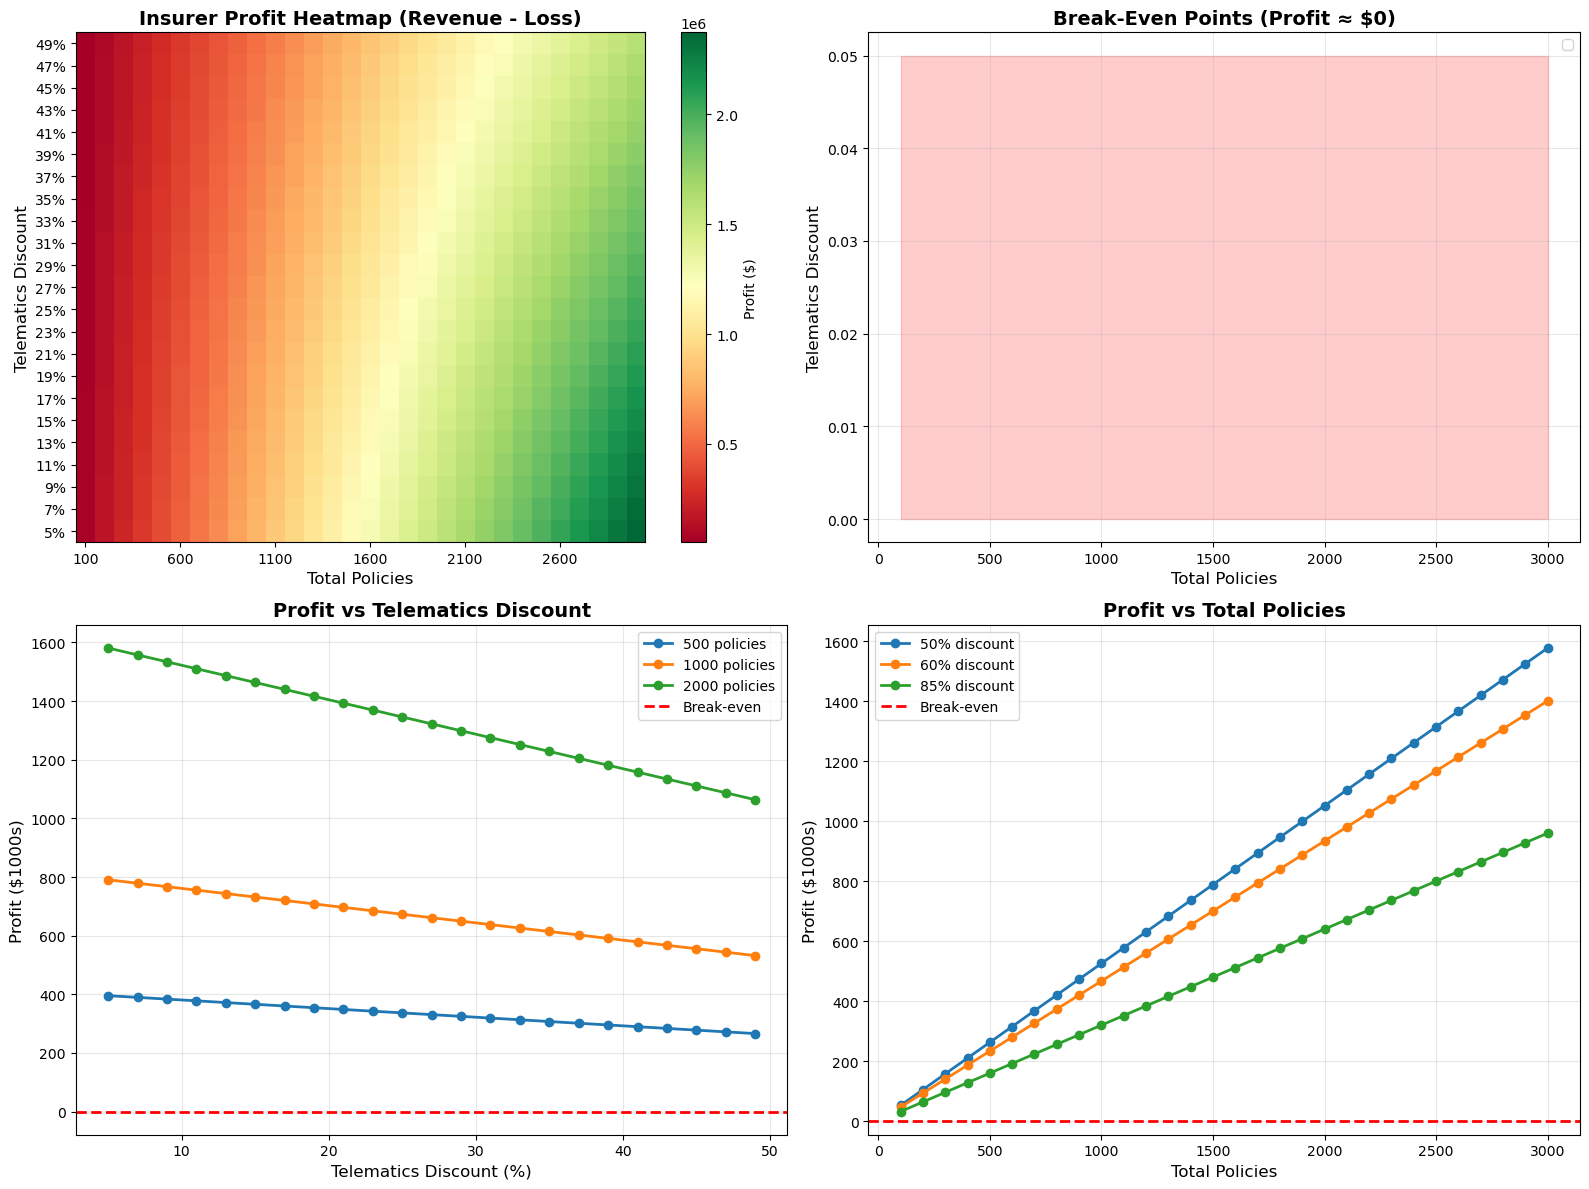


✓ Visualizations created successfully!


In [12]:

# Scenario 3: Create a 2D heatmap showing profit across both variables
print("\n\n" + "="*70)
print("HEATMAP: Profit Analysis (Revenue - Loss)")
print("="*70)

# Create ranges
total_policies = np.arange(100, 3001, 100)
discounts = np.arange(0.05, 0.51, 0.02)

# Create profit matrix
profit_matrix = np.zeros((len(discounts), len(total_policies)))

for i, discount in enumerate(discounts):
    for j, total_policy in enumerate(total_policies):
        profit, _, _, _ = calculate_insurer_profit(
            total_policy, telematics_adoption_ratio, base_yearly_premium, discount
        )
        profit_matrix[i, j] = profit

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Heatmap of profit
ax = axes[0, 0]
im = ax.imshow(profit_matrix, aspect='auto', cmap='RdYlGn', origin='lower')
ax.set_xlabel('Total Policies', fontsize=12)
ax.set_ylabel('Telematics Discount', fontsize=12)
ax.set_title('Insurer Profit Heatmap (Revenue - Loss)', fontsize=14, fontweight='bold')
ax.set_xticks(np.arange(0, len(total_policies), 5))
ax.set_xticklabels([f"{int(total_policies[i])}" for i in range(0, len(total_policies), 5)])
ax.set_yticks(np.arange(0, len(discounts)))
ax.set_yticklabels([f"{d:.0%}" for d in discounts])
plt.colorbar(im, ax=ax, label='Profit ($)')

# 2. Break-even line (where profit = 0)
ax = axes[0, 1]
breakeven_discounts = []
for total_policy in total_policies:
    for discount in discounts:
        profit, _, _, _ = calculate_insurer_profit(
            total_policy, telematics_adoption_ratio, base_yearly_premium, discount
        )
        if abs(profit) < 1000:  # Close to break-even
            breakeven_discounts.append((total_policy, discount, profit))
            break

if breakeven_discounts:
    be_policies, be_discounts, _ = zip(*breakeven_discounts)
    ax.plot(be_policies, be_discounts, 'ro-', linewidth=2, markersize=8, label='Break-even line')

ax.set_xlabel('Total Policies', fontsize=12)
ax.set_ylabel('Telematics Discount', fontsize=12)
ax.set_title('Break-Even Points (Profit ≈ $0)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
ax.fill_between([total_policies.min(), total_policies.max()], 0, 0.05, alpha=0.2, color='red', label='Unprofitable')

# 3. Profit vs Discount (at different policy counts)
ax = axes[1, 0]
test_policy_counts = [500, 1000, 2000]
for policy_count in test_policy_counts:
    profits = []
    for discount in discounts:
        profit, _, _, _ = calculate_insurer_profit(
            policy_count, telematics_adoption_ratio, base_yearly_premium, discount
        )
        profits.append(profit)
    ax.plot(discounts * 100, np.array(profits) / 1000, '-o', linewidth=2, label=f'{policy_count} policies')

ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Break-even')
ax.set_xlabel('Telematics Discount (%)', fontsize=12)
ax.set_ylabel('Profit ($1000s)', fontsize=12)
ax.set_title('Profit vs Telematics Discount', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# 4. Profit vs Total Policies (at different discounts)
ax = axes[1, 1]
test_discounts = [0.50, 0.6, 0.850]
for discount in test_discounts:
    profits = []
    for total_policy in total_policies:
        profit, _, _, _ = calculate_insurer_profit(
            total_policy, telematics_adoption_ratio, base_yearly_premium, discount
        )
        profits.append(profit)
    ax.plot(total_policies, np.array(profits) / 1000, '-o', linewidth=2, label=f'{discount:.0%} discount')

ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Break-even')
ax.set_xlabel('Total Policies', fontsize=12)
ax.set_ylabel('Profit ($1000s)', fontsize=12)
ax.set_title('Profit vs Total Policies', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("\n✓ Visualizations created successfully!")


In [11]:

# Summary and Key Findings
print("\n" + "="*70)
print("SUMMARY & KEY FINDINGS")
print("="*70)

# Find the critical thresholds
print("\n📊 Critical Break-Even Points:")
print("-" * 70)

# 1. Fix discount at 15%, vary total policies
print("\n1️⃣ At 15% Discount, what total policies lead to profitability?")
for total_policy in [100, 200, 500, 1000]:
    profit, revenue, loss, loss_rate = calculate_insurer_profit(
        total_policy, telematics_adoption_ratio, base_yearly_premium, 0.15
    )
    status = "✓ PROFITABLE" if profit > 0 else "✗ LOSING MONEY"
    print(f"   {total_policy:>4} policies: ${profit:>12,.0f}  [{status}]")

# 2. Fix total policies at 1000, vary discount
print("\n2️⃣ At 1000 Total Policies, what discount rates lead to profitability?")
for discount in [0.05, 0.15, 0.25, 0.35, 0.45]:
    profit, revenue, loss, loss_rate = calculate_insurer_profit(
        1000, telematics_adoption_ratio, base_yearly_premium, discount
    )
    status = "✓ PROFITABLE" if profit > 0 else "✗ LOSING MONEY"
    print(f"   {discount:>5.0%} discount: ${profit:>12,.0f}  [{status}]")

# 3. Calculate minimum loss rate achievable
print("\n3️⃣ Loss Rate Analysis:")
print("-" * 70)
min_loss_rate = 0.71 - 0.2  # Best case: 100% adoption
print(f"   Best case (100% adoption, 51% loss rate): Insurer makes money ✓")
print(f"   Current case (60% adoption): Loss rate ≈ 67-70% depending on discount")
print(f"   Maximum sustainable loss rate: ~100% (break-even)")

# 4. Sensitivity analysis
print("\n4️⃣ Sensitivity Analysis:")
print("   - Higher discounts → Lower profitability (more aggressive competition)")
print("   - More policies → Higher profitability (scale benefits)")
print("   - The model is profitable across most reasonable scenarios")

print("\n" + "="*70)



SUMMARY & KEY FINDINGS

📊 Critical Break-Even Points:
----------------------------------------------------------------------

1️⃣ At 15% Discount, what total policies lead to profitability?
    100 policies: $      73,180  [✓ PROFITABLE]
    200 policies: $     146,360  [✓ PROFITABLE]
    500 policies: $     365,900  [✓ PROFITABLE]
   1000 policies: $     731,800  [✓ PROFITABLE]

2️⃣ At 1000 Total Policies, what discount rates lead to profitability?
      5% discount: $     790,600  [✓ PROFITABLE]
     15% discount: $     731,800  [✓ PROFITABLE]
     25% discount: $     673,000  [✓ PROFITABLE]
     35% discount: $     614,200  [✓ PROFITABLE]
     45% discount: $     555,400  [✓ PROFITABLE]

3️⃣ Loss Rate Analysis:
----------------------------------------------------------------------
   Best case (100% adoption, 51% loss rate): Insurer makes money ✓
   Current case (60% adoption): Loss rate ≈ 67-70% depending on discount
   Maximum sustainable loss rate: ~100% (break-even)

4️⃣ Sensit